# Basic

In [ ]:
import torch

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(-4.0, requires_grad=True)

f = (x + y) ** 2 + 2 * x * y
f.backward()

print(f)
print(x.data, x.grad)
print(y.data, y.grad)

tensor(-12., grad_fn=<AddBackward0>)
tensor(2.) tensor(-12.)
tensor(-4.) tensor(0.)


In [8]:
import torch

def func(x):
    return 0.2 * (x - 2) ** 2 - 0.3 * torch.cos(4 * x)


x0 = 0.0 # начальное значение точки минимума
lr = 0.1 # шаг обучения
N = 200 # число итераций градиентного алгоритма

x = torch.tensor([x0], requires_grad=True)

for _ in range(N):
    y = func(x)
    y.backward()

    x.data = x.data - lr * x.grad
    x.grad.zero_()


tensor([0.4364], grad_fn=<SubBackward0>)

In [10]:
import torch
import torch.optim as optim

def func(x):
    return 0.2 * (x - 2) ** 2 - 0.3 * torch.cos(4 * x)


lr = 0.1 # шаг обучения
x0 = 0.0 # начальное значение точки минимума
N = 200 # число итераций градиентного алгоритма

x = torch.tensor([x0], requires_grad=True)
optimizer = optim.RMSprop(params=[x], lr=lr)

for _ in range(N):
    y = func(x)
    y.backward()

    optimizer.step()
    optimizer.zero_grad()

print(x, func(x))

tensor([1.6554], requires_grad=True) tensor([-0.2592], grad_fn=<SubBackward0>)


In [30]:
import numpy as np
import torch
import torch.optim as optim

n_features = 4 # число коэффициентов w
x = torch.arange(-3, 3, 0.1)
y_train = -0.1 * x + 0.2 * torch.sin(2 * x) - 0.1 * torch.cos(5 * x)
x_train = torch.tensor([[_x ** _n for _n in range(n_features)] for _x in x])

w = torch.FloatTensor(n_features).uniform_(-1e-5, 1e-5)
w.requires_grad_(True)

total = len(y_train)
lr = 0.01 # шаг обучения
N = 1000 # число итераций алгоритма SGD

np.random.seed(1) # установка "зерна" генератора датчика случайных чисел

# здесь продолжайте программу
model = lambda X, w: X @ w

loss_func = torch.nn.MSELoss()
optimizer = optim.RMSprop(params=[w], lr=lr)

for _ in range(N):
    k = np.random.randint(0, total)
    y = model(x_train[k], w)

    loss = loss_func(y, y_train[k])
    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

# Q = ((y_train - model(x_train, w)) ** 2).mean().item()
Q = loss_func(y_train, model(x_train, w)).item()
print(Q)

0.029087074100971222


0.9300000071525574
-0.09673826396465302


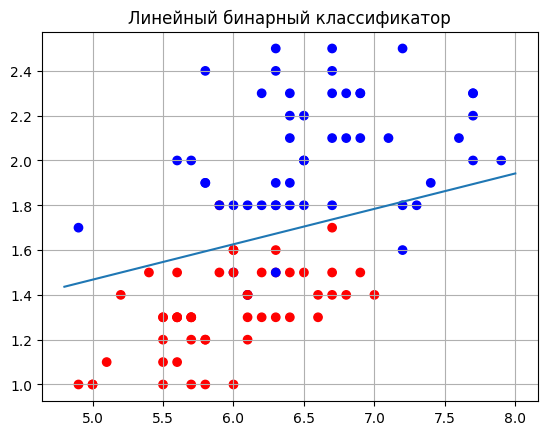

In [65]:
import numpy as np
import torch
import torch.optim as optim

x_train = torch.tensor([(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)])
y_train = torch.tensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1])
y_train = y_train.float()

total = len(y_train) # размер обучающей выборки
n_features = 3 # число параметров w0, w1, w2
lr = 0.1 # шаг обучения
N = 500 # число итераций градиентного алгоритма

np.random.seed(1) # установка "зерна" генератора датчика случайных чисел

X = torch.ones(total, 3)
X[:, 1:3] = x_train # матрица формата [(1, x11, x12), (1, x21, x22), ..., (1, xn1, xn2)]

w = torch.empty(n_features).uniform_(-1e-5, 1e-5) # начальные значения вектора w
w.requires_grad_(True)

# здесь продолжайте программу
model = lambda X, w: X @ w

loss_func = torch.nn.BCEWithLogitsLoss()
optimizer = optim.Adam(params=[w], lr=lr)

for _ in range(N):
    k = np.random.randint(0, total)
    y = model(X[k], w)

    loss = loss_func(y, y_train[k])
    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

print(torch.mean((torch.sign(model(X, w)) == (y_train * 2 - 1)).float()).item())

# Q = (torch.round(torch.sigmoid(X @ w)) == y_train).sum().item() / len(y_train)
print(Q)

import matplotlib.pyplot as plt

colors = 'rb'

plt.scatter(x_train[:, 0], x_train[:, 1], c=[colors[int(y)] for y in y_train])
x_plot = torch.linspace(4.8, 8.0, 10)
y_plot = ((-w[1] * x_plot - w[0]) / w[2]).detach().numpy()
plt.plot(x_plot, y_plot)
plt.grid()
plt.title("Линейный бинарный классификатор")
plt.show()

In [4]:
import torch
import torch.nn as nn

# тензор x в программе не менять
x = torch.tensor(list(map(float, input().split())), dtype=torch.float32)

# здесь продолжайте программу
layer = nn.Linear(in_features=16, out_features=1, bias=False)
layer.weight.data = torch.ones(1, 16)
y = layer(x)
print(f"{y.item():.1f}")

-1.6 7.8 3.6 0.1 3.7 5.9 -1.8 10.0 -0.6 -2.8 0.8 0.4 9.5 2.4 4.9 9.6
51.9


# Построение нейронных сетей

In [ ]:
from random import randint
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class GLM(nn.Module):

    def __init__(self, input_dim, num_hidden, output_dim) -> None:
        super().__init__()
        self.layer1 = nn.Linear(in_features=input_dim, out_features=num_hidden)
        self.layer2 = nn.Linear(num_hidden, output_dim)

    def forward(self, x):
        x = self.layer1(x)
        x = F.tanh(x)
        x = self.layer2(x)
        x = F.tanh(x)
        return x


model = GLM(3, 3, 2)
optimizer = optim.RMSprop(params=model.parameters(), lr=0.01)
loss_func = torch.nn.MSELoss()

n = 1000
x_train = torch.FloatTensor([(-1, -1, -1), (-1, -1, 1), (-1, 1, -1), (-1, 1, 1),
                            (1, -1, -1), (1, -1, 1), (1, 1, -1), (1, 1, 1)])
y_train = torch.FloatTensor([-1, 1, -1, 1, -1, 1, -1, -1])
total = len(y_train)

model.train()

for i in range(n):
    k = randint(0, total-1)
    y = model(x_train[k])
    loss = loss_func(y, y_train[k])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

model.eval()
for x, d in zip(x_train, y_train):
    with torch.no_grad():
        y = model(x)
        print(y.data, d)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([20])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor([-0.9826, -0.9758, -0.9819, -0.9713, -0.9836, -0.9819, -0.9815, -0.9822,
        -0.9646, -0.9814, -0.9755, -0.9696, -0.9796, -0.9834, -0.9760, -0.9715,
        -0.9790, -0.9695, -0.9649, -0.9748]) tensor(-1.)
tensor([0.9957, 0.9936, 0.9955, 0.9921, 0.9960, 0.9955, 0.9954, 0.9956, 0.9898,
        0.9953, 0.9935, 0.9916, 0.9948, 0.9959, 0.9937, 0.9922, 0.9947, 0.9915,
        0.9899, 0.9933]) tensor(1.)
tensor([-0.9981, -0.9969, -0.9980, -0.9960, -0.9982, -0.9980, -0.9979, -0.9980,
        -0.9946, -0.9979, -0.9968, -0.9957, -0.9976, -0.9982, -0.9969, -0.9961,
        -0.9975, -0.9956, -0.9946, -0.9967]) tensor(-1.)
tensor([0.9833, 0.9774, 0.9826, 0.9734, 0.9842, 0.9827, 0.9823, 0.9829, 0.9675,
        0.9822, 0.9771, 0.9719, 0.9806, 0.9840, 0.9775, 0.9736, 0.9802, 0.9718,
        0.9677, 0.9765]) tensor(1.)
tensor([-0.9981, -0.9970, -0.9980, -0.9961, -0.9983, -0.9980, -0.9980, -0.9981,
        -0.9947, -0.9979, -0.9969, -0.9958, -0.9976, -0.9983, -0.9970, -0.9961,
        -0.997

# NLP

In [ ]:
import torch.nn as nn
import torch.optim as optim

# Пример данных: пары (центральное слово, контекст)
data = [('king', 'queen'), ('man', 'king'), ('woman', 'queen'), ('apple', 'fruit')]

# Словарь и индексы
vocab = list(set([w for pair in data for w in pair]))
word_to_ix = {word: i for i, word in enumerate(vocab)}

# Параметры
embedding_dim = 5

class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.out = nn.Linear(embedding_dim, vocab_size)

    def forward(self, center_words):
        embeds = self.embeddings(center_words)
        out = self.out(embeds)
        return out

model = SkipGramModel(len(vocab), embedding_dim)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Обучение (упрощённый цикл)
for epoch in range(100):
    total_loss = 0
    for center, context in data:
        center_idx = torch.tensor([word_to_ix[center]], dtype=torch.long)
        context_idx = torch.tensor([word_to_ix[context]], dtype=torch.long)

        model.zero_grad()
        log_probs = model(center_idx)
        loss = loss_function(log_probs, context_idx)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

# Получение эмбеддингов
embeddings = model.embeddings.weight.data
print("Вектор слова 'king':", embeddings[word_to_ix['king']])


Epoch 0, Loss: 7.6415
Epoch 10, Loss: 5.6807
Epoch 20, Loss: 4.4203
Epoch 30, Loss: 3.6348
Epoch 40, Loss: 3.1227
Epoch 50, Loss: 2.7595
Epoch 60, Loss: 2.4791
Epoch 70, Loss: 2.2473
Epoch 80, Loss: 2.0454
Epoch 90, Loss: 1.8630
Вектор слова 'king': tensor([-0.7418, -0.9931, -1.7313,  1.2717, -0.0924])


AttributeError: 'SkipGramModel' object has no attribute 'wv'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
import numpy as np

# --- 1. Подготовка данных ---

corpus = [
    "king queen man woman child prince princess",
    "man woman child family father mother",
    "king queen castle throne royal",
    "prince princess royal family",
    "man king strong brave",
    "woman queen wise kind",
    "child play fun happy",
    "father mother family love"
]

# Токенизация и создание словаря
tokenized_corpus = [sentence.lower().split() for sentence in corpus]
vocab = set(word for sentence in tokenized_corpus for word in sentence)
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

# Создание обучающих пар (центральное слово, контекст)
window_size = 2
data = []

for sentence in tokenized_corpus:
    for i, center_word in enumerate(sentence):
        context_indices = list(range(max(0, i - window_size), i)) + \
                          list(range(i + 1, min(len(sentence), i + window_size + 1)))
        for j in context_indices:
            data.append((word2idx[center_word], word2idx[sentence[j]]))

# --- 2. Модель Skip-gram ---

class Word2VecSkipGram(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.in_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.out_embeddings = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, center_words):
        center_embeds = self.in_embeddings(center_words)  # (batch_size, embed_dim)
        scores = torch.matmul(center_embeds, self.out_embeddings.weight.t())  # (batch_size, vocab_size)
        log_probs = torch.log_softmax(scores, dim=1)
        return log_probs

# --- 3. Обучение ---

embedding_dim = 50
model = Word2VecSkipGram(len(vocab), embedding_dim)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_function = nn.NLLLoss()

# Подготовка батчей
def get_batches(data, batch_size):
    np.random.shuffle(data)
    s = 0
    while s < len(data):
        batch = data[s:s+batch_size]
        center_batch = torch.tensor([pair[0] for pair in batch], dtype=torch.long)
        context_batch = torch.tensor([pair[1] for pair in batch], dtype=torch.long)
        yield center_batch, context_batch
        s += batch_size

epochs = 200
batch_size = 16

for epoch in range(epochs):
    total_loss = 0
    for center_batch, context_batch in get_batches(data, batch_size):
        model.zero_grad()
        log_probs = model(center_batch)
        loss = loss_function(log_probs, context_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss:.4f}")

# --- 4. Аналогии: king - man + woman = ? ---

def analogy(word_a, word_b, word_c, model, word2idx, idx2word, topn=1):
    # Получаем векторы слов
    vec_a = model.in_embeddings.weight[word2idx[word_a]]
    vec_b = model.in_embeddings.weight[word2idx[word_b]]
    vec_c = model.in_embeddings.weight[word2idx[word_c]]

    # Вычисляем вектор аналогии
    target_vec = vec_a - vec_b + vec_c

    # Вычисляем косинусное сходство со всеми словами
    embeddings = model.in_embeddings.weight
    cos_sim = torch.nn.functional.cosine_similarity(target_vec.unsqueeze(0), embeddings)

    # Исключаем исходные слова из результатов
    for word in [word_a, word_b, word_c]:
        cos_sim[word2idx[word]] = -float('inf')

    # Находим топ-N наиболее похожих слов
    topk = torch.topk(cos_sim, topn)
    results = [(idx2word[idx.item()], sim.item()) for idx, sim in zip(topk.indices, topk.values)]
    return results

result = analogy('king', 'man', 'woman', model, word2idx, idx2word)
print("king - man + woman =", result)


Epoch 20/200, Loss: 11.4959
Epoch 40/200, Loss: 11.1917
Epoch 60/200, Loss: 11.1715
Epoch 80/200, Loss: 11.0471
Epoch 100/200, Loss: 11.2088
Epoch 120/200, Loss: 10.9991
Epoch 140/200, Loss: 11.2184
Epoch 160/200, Loss: 11.1083
Epoch 180/200, Loss: 11.3168
Epoch 200/200, Loss: 10.8858
king - man + woman = [('wise', 0.2436407506465912)]


*BERT*

Для обучения и тонкой настройки BERT используйте класс Trainer из transformers.

Для более сложных задач (генерация текста, QA, NER) есть готовые модели и примеры на Hugging Face.


In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# Загружаем предобученный токенизатор и модель (двухклассовая классификация)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Пример текстов и меток
texts = ["I love programming.", "I hate bugs."]
labels = [1, 0]  # 1 - положительный, 0 - отрицательный

# Токенизация с паддингом и усечением
encodings = tokenizer(texts, truncation=True, padding=True, return_tensors='pt')

inputs = encodings['input_ids']
attention_masks = encodings['attention_mask']
labels_tensor = torch.tensor(labels)

# Прогон через модель
outputs = model(input_ids=inputs, attention_mask=attention_masks, labels=labels_tensor)

loss = outputs.loss
logits = outputs.logits

print(f"Loss: {loss.item()}")
print(f"Logits: {logits}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loss: 0.7369852066040039
Logits: tensor([[-0.4106,  0.3064],
        [-0.4550,  0.2046]], grad_fn=<AddmmBackward0>)


In [ ]:
from transformers import BertTokenizer, BertForNextSentencePrediction
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForNextSentencePrediction.from_pretrained('bert-base-uncased')

sentence_A = "I went to the store."
sentence_B = "There I bought some bread."

encoding = tokenizer.encode_plus(sentence_A, sentence_B, return_tensors='pt')

outputs = model(**encoding)
logits = outputs.logits
prediction = torch.argmax(logits)

if prediction.item() == 0:
    print("Предложения не связаны")
else:
    print("Предложения связаны")


Предложения не связаны


In [ ]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

sentence = "BERT is a powerful model for NLP."

inputs = tokenizer(sentence, return_tensors='pt')
outputs = model(**inputs)

# Получаем последний скрытый слой (batch_size, seq_len, hidden_size)
last_hidden_states = outputs.last_hidden_state

# Усредняем по всем токенам, чтобы получить вектор предложения
sentence_embedding = torch.mean(last_hidden_states, dim=1)

print(sentence_embedding)


tensor([[-4.2939e-01, -5.2378e-01,  3.6622e-01,  7.8488e-02, -6.2499e-02,
         -4.7923e-01, -1.0831e-01, -3.0264e-01,  1.9828e-01,  7.0227e-03,
         -9.2469e-02,  1.4533e-01,  1.0711e-02,  1.7477e-01,  2.0778e-02,
          4.8398e-02, -1.6978e-01,  9.8586e-02,  1.9419e-01, -1.3838e-01,
          6.6980e-02, -1.1729e-01, -7.0549e-02,  4.6972e-02,  3.1066e-03,
          1.0472e-01,  3.6584e-01, -1.2808e-01, -1.6370e-01,  1.5567e-01,
         -1.3387e-01,  3.2678e-01,  7.3862e-02, -3.9689e-01, -1.5944e-01,
          1.6209e-02,  9.9321e-02,  1.7363e-01,  5.2585e-02,  1.4588e-01,
         -3.3323e-01, -4.3272e-01,  1.0629e-01,  3.3762e-01, -1.1452e-01,
         -3.0234e-01, -1.8397e-01, -1.3689e-01,  1.8896e-01, -4.9339e-01,
         -1.1287e+00,  3.0626e-01, -4.2517e-01,  2.6160e-01,  4.5270e-01,
          5.1102e-02,  4.9186e-01, -7.1490e-01,  3.1805e-01,  1.5652e-02,
         -1.9025e-01, -9.0524e-02, -9.9077e-02, -4.1108e-01,  4.3164e-01,
          2.1594e-01, -2.4561e-01,  1.